Database Path: C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
Connected to the database at C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
             date_time  close_price
0  2024-11-01 09:30:00   221.429993
1  2024-11-01 09:31:00   222.070007
2  2024-11-01 09:32:00   221.259995
3  2024-11-01 09:33:00   221.559998
4  2024-11-01 09:34:00   222.240005


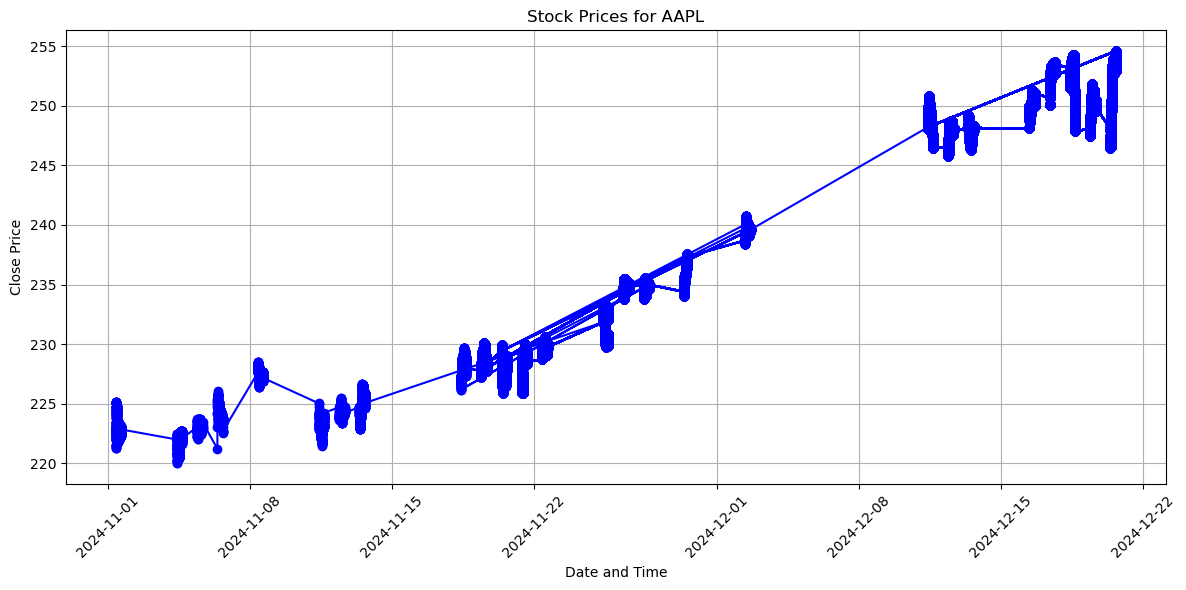

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os

# Construct the path to the database
BASE_DIR = r'C:\Users\91940\Documents\Trade_buddy\scripts'
DB_PATH = os.path.join(BASE_DIR, 'C:/Users/91940/Documents/Trade_buddy/data/processed/stock_data.db')

# Normalize the path to handle '..'
DB_PATH = os.path.normpath(DB_PATH)

# Print to confirm the correct path
print("Database Path:", DB_PATH)
SQL_PATH = os.path.join(BASE_DIR, '../models/create_tables.sql')

def create_connection():
    """ Create a database connection to the SQLite database """
    conn = None
    try:
        conn = sqlite3.connect(DB_PATH)
        print(f"Connected to the database at {DB_PATH}")
    except sqlite3.Error as e:
        print(f"Error connecting to the database: {e}")
    return conn

def visualize_stock_data(ticker):
    """ Visualize stock prices from the database """
    conn = create_connection()
    if conn:
        query = f"SELECT date_time, close_price FROM exclude_weekend_data WHERE ticker='{ticker}'"
        df = pd.read_sql_query(query, conn)
        print(df.head())
        conn.close()

        # Convert date_time to datetime for plotting
        df['date_time'] = pd.to_datetime(df['date_time'])

        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(df['date_time'], df['close_price'], marker='o', linestyle='-', color='b')
        plt.title(f'Stock Prices for {ticker}')
        plt.xlabel('Date and Time')
        plt.ylabel('Close Price')
        plt.xticks(rotation=45)
        plt.grid()
        plt.tight_layout()
        plt.show()
    
if __name__ == '__main__':
    ticker = 'AAPL'  # Example: Fetch and store Apple's stock data
    visualize_stock_data(ticker)

In [8]:
conn = create_connection()
if conn:
    query = f"SELECT * FROM stock_data WHERE ticker='{ticker}'"
    df = pd.read_sql_query(query, conn)
    print(df.head(),len(df))
    conn.close()
    

Connected to the database at C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
   id ticker            date_time  open_price  high_price   low_price  \
0   1   AAPL  2024-11-01 09:30:00  220.970001  221.830002  220.279999   
1   2   AAPL  2024-11-01 09:31:00  221.384995  222.330002  221.028107   
2   3   AAPL  2024-11-01 09:32:00  222.160004  222.300003  221.190002   
3   4   AAPL  2024-11-01 09:33:00  221.259995  222.039993  221.169998   
4   5   AAPL  2024-11-01 09:34:00  221.550003  222.240005  221.529999   

   close_price   volume  
0   221.429993  4690276  
1   222.070007   659814  
2   221.259995   543082  
3   221.559998   550074  
4   222.240005   466803   570489


In [31]:
conn = create_connection()
if conn:
    query = f"SELECT * FROM exclude_weekend_data WHERE ticker='{ticker}'"
    df = pd.read_sql_query(query, conn)
    print(df.head(),len(df))
    conn.close()
    

Connected to the database at C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
  ticker  date            date_time  close_price   volume
0   AAPL     5  2024-11-01 09:30:00   221.429993  4690276
1   AAPL     5  2024-11-01 09:31:00   222.070007   659814
2   AAPL     5  2024-11-01 09:32:00   221.259995   543082
3   AAPL     5  2024-11-01 09:33:00   221.559998   550074
4   AAPL     5  2024-11-01 09:34:00   222.240005   466803 757149


In [34]:
import yfinance as yf
stock = yf.Ticker(ticker)
stock.history(period="10d", interval="1h") 

c:\Users\91940\anaconda3\envs\trade\Lib\site-packages\yfinance\utils.py:633: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if not _np.isnan(quotes["High"][n - 1]):
c:\Users\91940\anaconda3\envs\trade\Lib\site-packages\yfinance\utils.py:634: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  quotes.loc[idx2, "High"] = _np.nanmax([quotes["High"][n - 1], quotes["High"][n - 2]])
c:\Users\91940\anaconda3\envs\trade\Lib\site-packages\yfinance\utils.py:638: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-11-14 09:30:00-05:00,225.070007,226.600006,225.050003,226.570007,8366080,0.0,0.0
2024-11-14 10:30:00-05:00,226.565002,227.059998,226.339996,226.419998,4306234,0.0,0.0
2024-11-14 11:30:00-05:00,226.580002,227.080002,226.509995,227.000000,2369653,0.0,0.0
2024-11-14 12:30:00-05:00,227.009995,228.639999,226.770004,228.472794,4327298,0.0,0.0
2024-11-14 13:30:00-05:00,228.470093,228.869995,227.830002,228.527496,3310597,0.0,0.0
...,...,...,...,...,...,...,...
2024-11-27 11:30:00-05:00,234.620102,234.889999,233.979996,234.570007,2845831,0.0,0.0
2024-11-27 12:30:00-05:00,234.559998,235.000000,234.409393,234.780106,2325512,0.0,0.0
2024-11-27 13:30:00-05:00,234.779999,235.137100,234.710007,234.979996,1683157,0.0,0.0
